In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/raw/spotify-tracks-dataset.csv")

In [4]:
df.shape

(114000, 22)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      114000 non-null  int64  
 1   Unnamed: 0        114000 non-null  int64  
 2   track_id          114000 non-null  str    
 3   artists           113999 non-null  str    
 4   album_name        113999 non-null  str    
 5   track_name        113999 non-null  str    
 6   popularity        114000 non-null  int64  
 7   duration_ms       114000 non-null  int64  
 8   explicit          114000 non-null  bool   
 9   danceability      114000 non-null  float64
 10  energy            114000 non-null  float64
 11  key               114000 non-null  int64  
 12  loudness          114000 non-null  float64
 13  mode              114000 non-null  int64  
 14  speechiness       114000 non-null  float64
 15  acousticness      114000 non-null  float64
 16  instrumentalness  114000 non-nu

In [6]:
df.head()

,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [7]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'track_id', 'artists', 'album_name',
       'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability',
       'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='str')

In [8]:
df = df.drop(columns=["Unnamed: 0.1", "Unnamed: 0"])
df.shape

(114000, 20)

In [9]:
df[df["track_name"].isnull()]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [10]:
df["track_genre"].nunique()
df["track_genre"].value_counts()

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
               ... 
techno         1000
trance         1000
trip-hop       1000
turkish        1000
world-music    1000
Name: count, Length: 114, dtype: int64

In [11]:
df = df.dropna(subset = ["track_name"])
df.shape

(113999, 20)

In [12]:
df[["danceability","energy","valence","acousticness","tempo"]].describe()

,danceability,energy,valence,acousticness,tempo
count,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,0.566801,0.641383,0.474066,0.314907,122.147695
std,0.173543,0.251530,0.259261,0.332522,29.978290
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.456000,0.472000,0.260000,0.016900,99.218500
50%,0.580000,0.685000,0.464000,0.169000,122.017000
75%,0.695000,0.854000,0.683000,0.597500,140.071000
max,0.985000,1.000000,0.995000,0.996000,243.372000


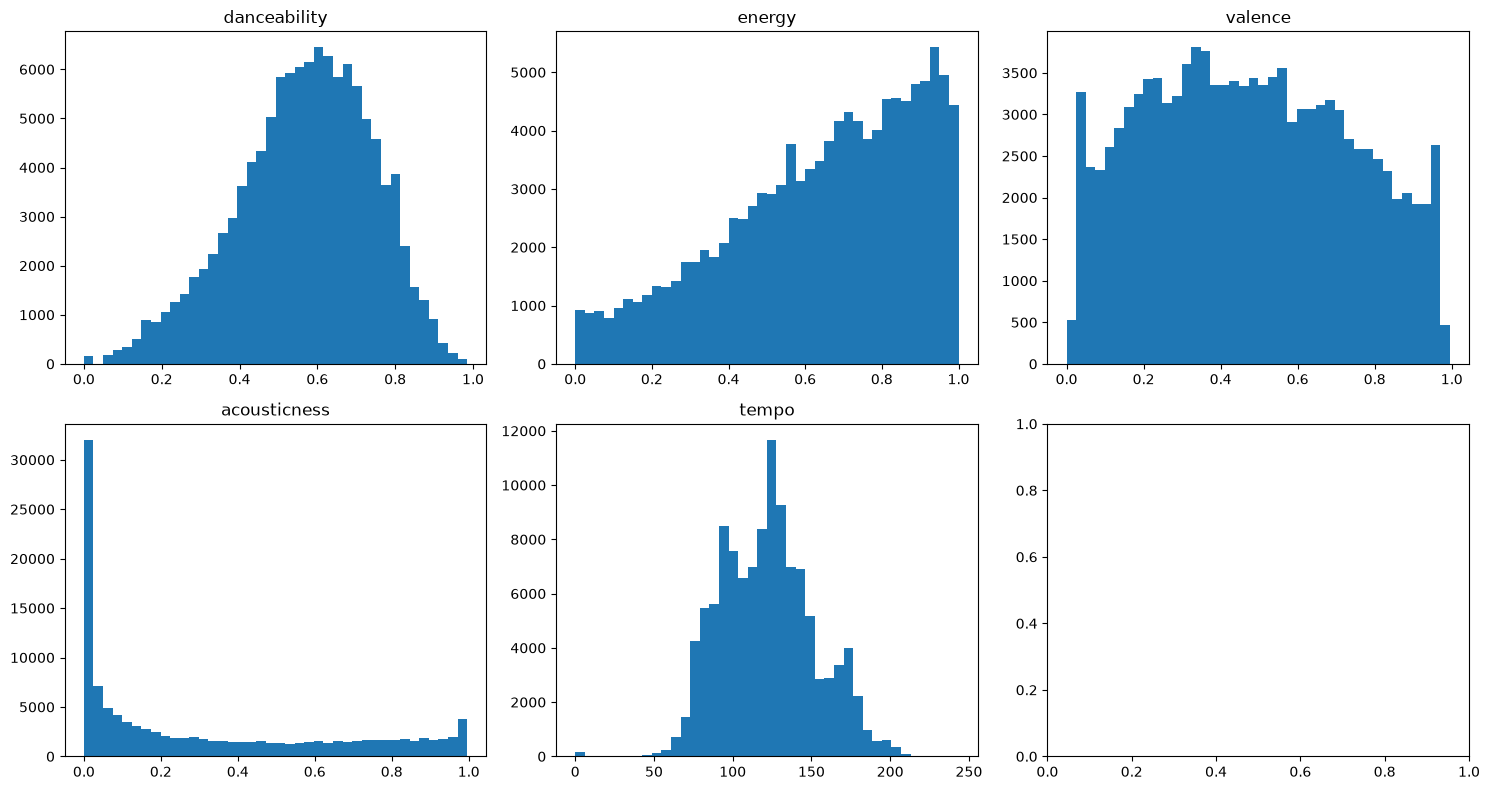

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

features = ["danceability", "energy", "valence", "acousticness", "tempo"]

for i, feature in enumerate(features):
    row, col = i // 3, i % 3
    axes[row][col].hist(df[feature], bins=40)
    axes[row][col].set_title(feature)

plt.tight_layout()
plt.show()

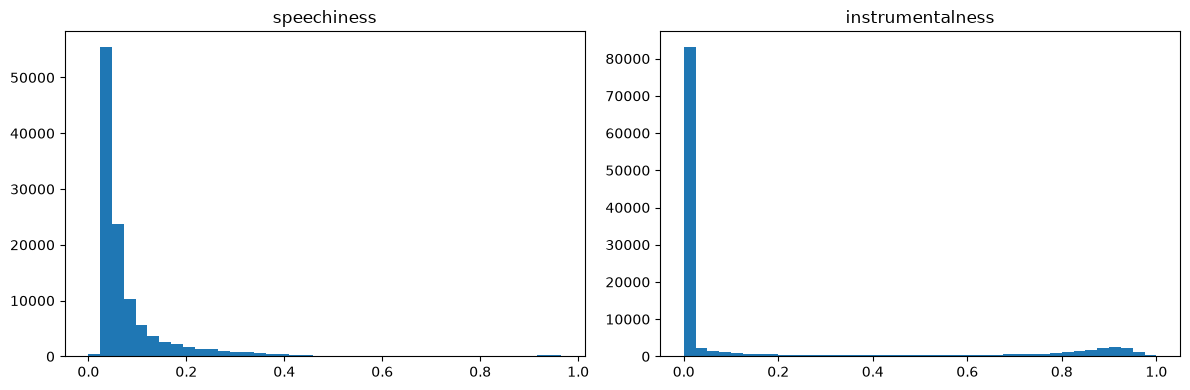

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["speechiness"], bins=40)
axes[0].set_title("speechiness")

axes[1].hist(df["instrumentalness"], bins=40)
axes[1].set_title("instrumentalness")

plt.tight_layout()
plt.show()

In [15]:
features = ["danceability", "energy", "valence", "acousticness", "speechiness", "instrumentalness", "tempo"]

correlation_matrix = df[features].corr()
correlation_matrix

,danceability,energy,valence,acousticness,speechiness,instrumentalness,tempo
danceability,1.000000,0.134325,0.477347,-0.171531,0.108625,-0.185608,-0.050448
energy,0.134325,1.000000,0.258937,-0.733908,0.142508,-0.181880,0.247852
valence,0.477347,0.258937,1.000000,-0.107081,0.036637,-0.324310,0.078269
acousticness,-0.171531,-0.733908,-0.107081,1.000000,-0.002184,0.104033,-0.208231
speechiness,0.108625,0.142508,0.036637,-0.002184,1.000000,-0.089617,0.017274
instrumentalness,-0.185608,-0.181880,-0.324310,0.104033,-0.089617,1.000000,-0.050328
tempo,-0.050448,0.247852,0.078269,-0.208231,0.017274,-0.050328,1.000000


In [16]:
from sklearn.preprocessing import StandardScaler

features = ["danceability", "energy", "valence", "acousticness", "speechiness", "instrumentalness", "tempo"]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[features])

scaled_features[:5]

array([[ 0.62923855, -0.71714698,  0.92931467, -0.85019263,  0.55184323,
        -0.50411124, -1.14185449],
       [-0.84590813, -1.88997393, -0.79868091,  1.83174449, -0.07899498,
        -0.50409654, -1.48970775],
       [-0.74218688, -1.12266681, -1.36567947, -0.31548931, -0.27382657,
        -0.5041145 , -1.52830252],
       [-1.73330106, -2.31298677, -1.27696541,  1.77460521, -0.45730875,
        -0.50388611,  1.98785744],
       [ 0.29502563, -0.78870931, -1.18439421,  0.46340923, -0.30314589,
        -0.5041145 , -0.07334322]])